# Análisis de Regresión Logística para Predicción de Enfermedades Cardíacas

# 1. Análisis Exploratorio de Datos python

In [51]:
#Cargar las librerias necesarias

import pandas as pd # Manejo y análisis de estructuras de datos
import numpy as np # Cálculo numérico y el análisis de datos
import seaborn as sns # Creación gráficos estadísticos
import matplotlib.pyplot as plt # Creación de gráficos en dos dimensiones

# librerías de para implementar modelos de ciencia de datos
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

Este bloque importa todas las bibliotecas necesarias para el análisis:

Pandas para manipulación de datos

Numpy para operaciones numéricas

Seaborn y Matplotlib para visualización

Scikit-learn para modelos de machine learning y métricas

In [53]:
# lectura de datos en Python y lo cargamos en la variable Datos

Datos = pd.read_excel('C:\\Users\\X\\OneDrive\\Documentos\\ANALISIS\\CORAZON.xlsx')

Carga el dataset desde un archivo Excel. Este contiene información sobre pacientes y posibles indicadores de enfermedades cardíacas.

In [55]:
# Realizamos lectura de los Datos para el análisis exploratorio

Datos.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,18,0,2,0,0
2,66,0,0,150,226,0,0,114,0,26,2,0,0,0
3,65,1,0,138,282,1,2,174,0,14,1,1,0,1
4,64,1,0,110,211,0,2,144,1,18,1,0,0,0
5,64,1,0,170,227,0,2,155,0,6,1,0,2,0
6,63,1,0,145,233,1,2,150,0,23,2,0,1,0
7,61,1,0,134,234,0,0,145,0,26,1,2,0,1
8,60,0,0,150,240,0,0,171,0,9,0,0,0,0
9,59,1,0,178,270,0,2,145,0,42,2,0,2,0


Muestra las primeras 10 filas del dataset para una inspección inicial de los datos.

# Renombra las columnas del dataset a nombres más descriptivos en español, lo que facilita la interpretación de las variables.

In [57]:
# Renombrar columnas para mayor claridad
nuevos_nombres = {
    'age': 'edad',
    'sex': 'sexo',  # 1 = masculino, 0 = femenino
    'cp': 'tipo_dolor_pecho',  # 0-3: tipos de dolor
    'trestbps': 'presion_reposo',  # en mm Hg
    'chol': 'colesterol',  # mg/dl
    'fbs': 'glucosa_ayunas',  # >120 mg/dl (1=sí, 0=no)
    'restecg': 'electro_reposo',  # resultados electrocardiográficos
    'thalach': 'frecuencia_maxima',  # frecuencia cardíaca máxima
    'exang': 'angina_ejercicio',  # angina inducida por ejercicio
    'oldpeak': 'depresion_st',  # depresión del segmento ST
    'slope': 'pendiente_st',  # pendiente del segmento ST
    'ca': 'vasos_principales',  # número de vasos principales
    'thal': 'resultado_talio',  # prueba de talio
    'condition': 'enfermedad_cardiaca'  # variable objetivo
}

Datos = Datos.rename(columns=nuevos_nombres)

# Verificación inicial
print(Datos.info())
print(Datos.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   edad                 297 non-null    int64
 1   sexo                 297 non-null    int64
 2   tipo_dolor_pecho     297 non-null    int64
 3   presion_reposo       297 non-null    int64
 4   colesterol           297 non-null    int64
 5   glucosa_ayunas       297 non-null    int64
 6   electro_reposo       297 non-null    int64
 7   frecuencia_maxima    297 non-null    int64
 8   angina_ejercicio     297 non-null    int64
 9   depresion_st         297 non-null    int64
 10  pendiente_st         297 non-null    int64
 11  vasos_principales    297 non-null    int64
 12  resultado_talio      297 non-null    int64
 13  enfermedad_cardiaca  297 non-null    int64
dtypes: int64(14)
memory usage: 32.6 KB
None
   edad  sexo  tipo_dolor_pecho  presion_reposo  colesterol  glucosa_ayunas  \
0  

# Muestra información sobre la estructura del dataset (tipos de datos, valores no nulos) y las primeras filas para verificar los cambios.

In [59]:
# Realizamos lectura de los Datos para el análisis exploratorio

Datos.head(10)

,edad,sexo,tipo_dolor_pecho,presion_reposo,colesterol,glucosa_ayunas,electro_reposo,frecuencia_maxima,angina_ejercicio,depresion_st,pendiente_st,vasos_principales,resultado_talio,enfermedad_cardiaca
0,69,1,0,160,234,1,2,131,0,1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,18,0,2,0,0
2,66,0,0,150,226,0,0,114,0,26,2,0,0,0
3,65,1,0,138,282,1,2,174,0,14,1,1,0,1
4,64,1,0,110,211,0,2,144,1,18,1,0,0,0
5,64,1,0,170,227,0,2,155,0,6,1,0,2,0
6,63,1,0,145,233,1,2,150,0,23,2,0,1,0
7,61,1,0,134,234,0,0,145,0,26,1,2,0,1
8,60,0,0,150,240,0,0,171,0,9,0,0,0,0
9,59,1,0,178,270,0,2,145,0,42,2,0,2,0


In [61]:
# Ver valores faltantes
print("Valores faltantes por columna:")
print(Datos.isnull().sum())

Valores faltantes por columna:
edad                   0
sexo                   0
tipo_dolor_pecho       0
presion_reposo         0
colesterol             0
glucosa_ayunas         0
electro_reposo         0
frecuencia_maxima      0
angina_ejercicio       0
depresion_st           0
pendiente_st           0
vasos_principales      0
resultado_talio        0
enfermedad_cardiaca    0
dtype: int64


Verifica si hay valores faltantes en el dataset, lo cual es crucial para el preprocesamiento posterior.

In [63]:
Datos_original = Datos.copy()

Crea una copia del dataset original para preservar los datos sin modificar.

# 2. Preprocesamiento de Datos

# Creamos los Box Plot para identificar los datos atipicos que se presenten en el cojunto de datos

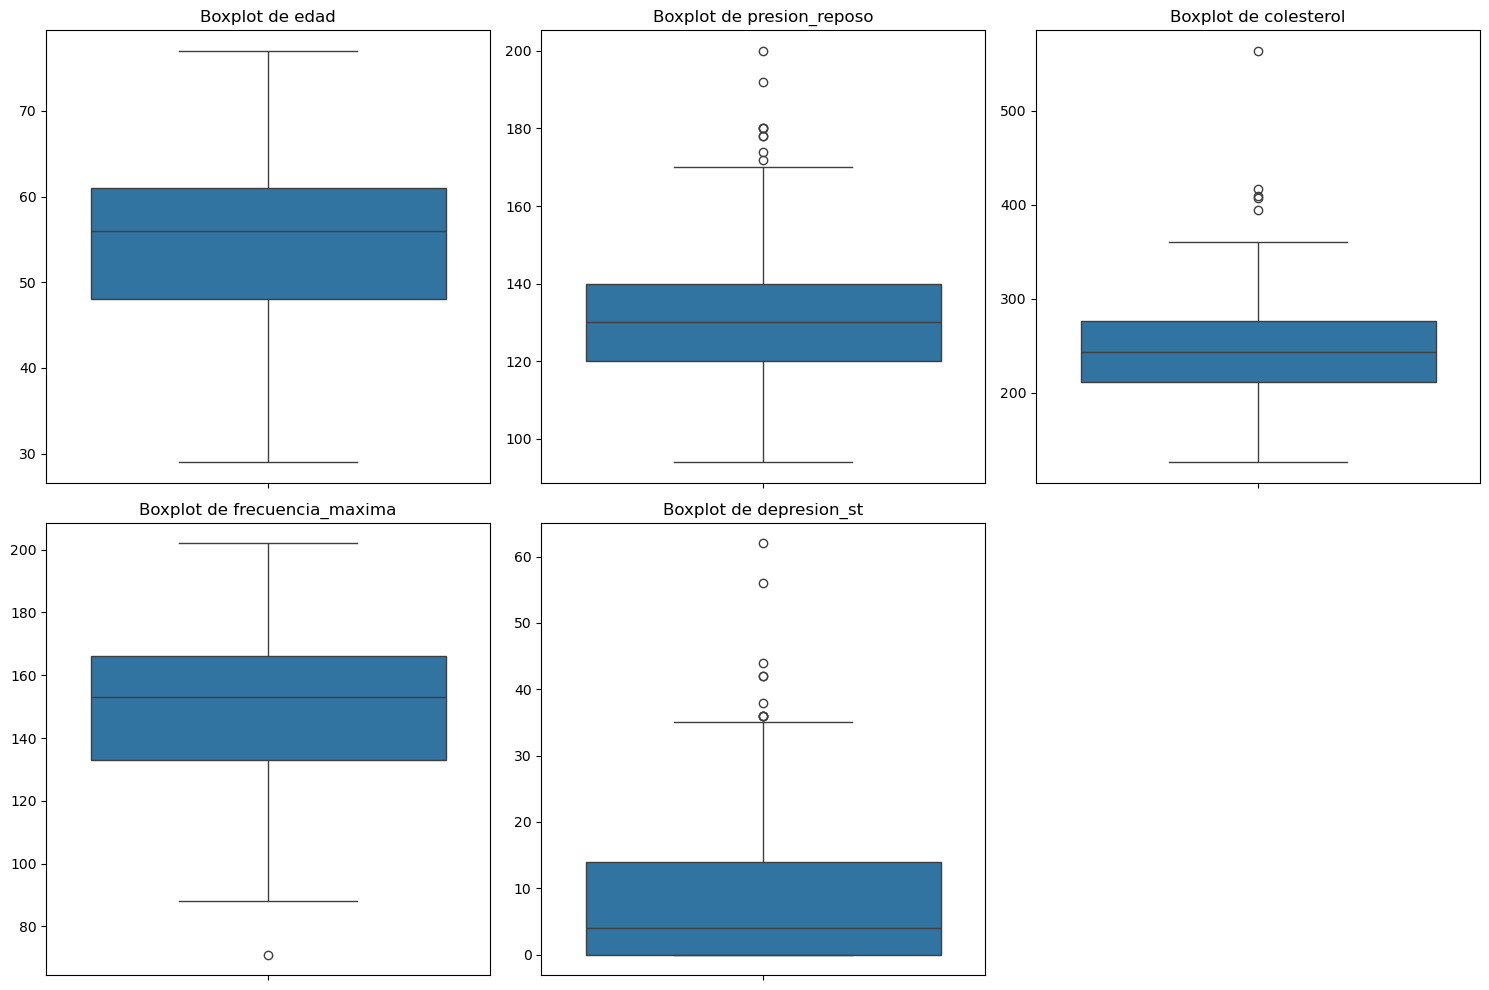

In [65]:
# Configurar el tamaño de los gráficos
plt.figure(figsize=(15, 10))

# Variables numéricas a analizar
variables_numericas = ['edad', 'presion_reposo', 'colesterol', 'frecuencia_maxima', 'depresion_st']

# Crear boxplots para cada variable
for i, columna in enumerate(variables_numericas, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=Datos[columna])
    plt.title(f'Boxplot de {columna}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

Se puedde evindeciar que hay datos atipicos y se salen de su proprocion

In [67]:
Datos[(Datos['presion_reposo'] < 90) | (Datos['presion_reposo'] > 180)]

,edad,sexo,tipo_dolor_pecho,presion_reposo,colesterol,glucosa_ayunas,electro_reposo,frecuencia_maxima,angina_ejercicio,depresion_st,pendiente_st,vasos_principales,resultado_talio,enfermedad_cardiaca
45,54,1,1,192,283,0,2,195,0,0,0,1,2,1
234,56,0,3,200,288,1,2,133,1,4,2,2,2,1


# Se establecen limites correctos para cada columna, esto lo hago para poder identificar cuales son los datos atipicos, por ejemplo una presion cardiaca de mas 200 es posible pero ya le esta dando un infarto a la persona o con el colesterol, lo normal es de 100 - 400, ya un colesterol mas de esto es un dato atipico

In [69]:
# Definir los rangos aceptables para cada variable
limites = {
    'edad': (20, 100),  # Edad en años
    'presion_reposo': (90, 180),  # Presión arterial en mmHg
    'colesterol': (100, 400),  # Colesterol en mg/dl
    'frecuencia_maxima': (60, 220),  # Frecuencia cardíaca en lpm
    'depresion_st': (0, 6),  # Depresión del ST en mm
    'vasos_principales': (0, 3),  # Número de vasos (0-3)
    'resultado_talio': {3, 6, 7}  # Valores aceptados para talio
}

# Función para identificar valores atípicos
def identificar_atipicos(columna, limite_inf=None, limite_sup=None, valores_aceptados=None):
    if valores_aceptados is not None:
        # Para variables categóricas con valores específicos
        atipicos = Datos[~Datos[columna].isin(valores_aceptados)]
        print(f"\nValores atípicos en '{columna}': (valores aceptados: {valores_aceptados})")
    else:
        # Para variables numéricas con rangos
        atipicos = Datos[(Datos[columna] < limite_inf) | (Datos[columna] > limite_sup)]
        print(f"\nValores atípicos en '{columna}': (rango aceptado: {limite_inf}-{limite_sup})")
    
    if not atipicos.empty:
        display(atipicos[[columna]])
        print(f"Número de valores atípicos: {len(atipicos)}")
    else:
        print("No se encontraron valores atípicos")
    
    return atipicos

# Identificar atípicos para cada columna
atipicos_edad = identificar_atipicos('edad', *limites['edad'])
atipicos_presion = identificar_atipicos('presion_reposo', *limites['presion_reposo'])
atipicos_colesterol = identificar_atipicos('colesterol', *limites['colesterol'])
atipicos_frecuencia = identificar_atipicos('frecuencia_maxima', *limites['frecuencia_maxima'])
atipicos_depresion = identificar_atipicos('depresion_st', *limites['depresion_st'])
atipicos_vasos = identificar_atipicos('vasos_principales', *limites['vasos_principales'])
atipicos_talio = identificar_atipicos('resultado_talio', valores_aceptados=limites['resultado_talio'])

# Para variables categóricas con valores binarios (0 y 1)
variables_binarias = {
    'sexo': {0, 1},
    'glucosa_ayunas': {0, 1},
    'angina_ejercicio': {0, 1},
    'enfermedad_cardiaca': {0, 1}
}

for columna, valores in variables_binarias.items():
    atipicos = Datos[~Datos[columna].isin(valores)]
    if not atipicos.empty:
        print(f"\nValores atípicos en '{columna}': (valores aceptados: {valores})")
        display(atipicos[[columna]])
        print(f"Número de valores atípicos: {len(atipicos)}")
    else:
        print(f"\nNo se encontraron valores atípicos en '{columna}'")


Valores atípicos en 'edad': (rango aceptado: 20-100)
No se encontraron valores atípicos

Valores atípicos en 'presion_reposo': (rango aceptado: 90-180)


,presion_reposo
45,192
234,200


Número de valores atípicos: 2

Valores atípicos en 'colesterol': (rango aceptado: 100-400)


,colesterol
79,564
83,417
180,407
238,409


Número de valores atípicos: 4

Valores atípicos en 'frecuencia_maxima': (rango aceptado: 60-220)
No se encontraron valores atípicos

Valores atípicos en 'depresion_st': (rango aceptado: 0-6)


,depresion_st
1,18
2,26
3,14
4,18
6,23
...,...
285,15
288,18
293,12
294,16


Número de valores atípicos: 123

Valores atípicos en 'vasos_principales': (rango aceptado: 0-3)
No se encontraron valores atípicos

Valores atípicos en 'resultado_talio': (valores aceptados: {3, 6, 7})


,resultado_talio
0,0
1,0
2,0
3,0
4,0
...,...
292,2
293,2
294,2
295,0


Número de valores atípicos: 297

No se encontraron valores atípicos en 'sexo'

No se encontraron valores atípicos en 'glucosa_ayunas'

No se encontraron valores atípicos en 'angina_ejercicio'

No se encontraron valores atípicos en 'enfermedad_cardiaca'


In [71]:
cambios_realizados = {
    'presion_reposo': 'Valores <90 llevados a 90, >180 llevados a 180',
    'colesterol': 'Valores >400 reemplazados por mediana por edad',
    # ... otros cambios
}

In [102]:
# Antes de hacer cambios, guardamos una copia del dataset original
Datos_original = Datos.copy()

# 1. Corrección para presión arterial
Datos.loc[Datos['presion_reposo'] < 90, 'presion_reposo'] = 90
Datos.loc[Datos['presion_reposo'] > 180, 'presion_reposo'] = 180

# 2. Corrección para colesterol (asumiendo que valores >400 son errores)
# Opción A: Reemplazar con la mediana del grupo de edad
Datos['colesterol_corregido'] = Datos['colesterol'].astype(float)
mediana_por_edad = Datos.groupby('edad')['colesterol'].transform('median')
Datos.loc[Datos['colesterol'] > 400, 'colesterol_corregido'] = mediana_por_edad

# Opción B: Si prefieres eliminar estos registros
# Datos = Datos[Datos['colesterol'] <= 400]

# 3. Corrección para depresión ST
Datos.loc[Datos['depresion_st'] > 6, 'depresion_st'] = 6  # Límite superior fisiológico

# 4. Corrección para resultado talio
valores_validos_talio = [3, 6, 7]
moda_talio = Datos['resultado_talio'].mode()[0]
Datos.loc[~Datos['resultado_talio'].isin(valores_validos_talio), 'resultado_talio'] = moda_talio

# 5. Corrección para vasos principales
Datos.loc[~Datos['vasos_principales'].isin([0,1,2,3]), 'vasos_principales'] = 0  # Asumir que no hay obstrucción

# Se verifica la correcion de los datos 

In [76]:
# Función para verificar correcciones
def verificar_correccion(columna, limite_inf=None, limite_sup=None, valores_aceptados=None):
    if valores_aceptados:
        incorrectos = Datos[~Datos[columna].isin(valores_aceptados)]
    else:
        incorrectos = Datos[(Datos[columna] < limite_inf) | (Datos[columna] > limite_sup)]
    
    if incorrectos.empty:
        print(f"✓ {columna}: Todos los valores están dentro de los parámetros aceptables")
    else:
        print(f"✗ {columna}: Aún hay {len(incorrectos)} valores fuera de rango")

# Verificamos cada variable
verificar_correccion('presion_reposo', 90, 180)
verificar_correccion('colesterol_corregido', 100, 400)
verificar_correccion('depresion_st', 0, 6)
verificar_correccion('resultado_talio', valores_aceptados=[3,6,7])
verificar_correccion('vasos_principales', valores_aceptados=[0,1,2,3])

✓ presion_reposo: Todos los valores están dentro de los parámetros aceptables
✓ colesterol_corregido: Todos los valores están dentro de los parámetros aceptables
✓ depresion_st: Todos los valores están dentro de los parámetros aceptables
✗ resultado_talio: Aún hay 297 valores fuera de rango
✓ vasos_principales: Todos los valores están dentro de los parámetros aceptables


In [80]:
# 4. Corrección para resultado talio
valores_validos_talio = [3, 6, 7]
moda_talio = Datos['resultado_talio'].mode()[0]
Datos.loc[~Datos['resultado_talio'].isin(valores_validos_talio), 'resultado_talio'] = moda_talio

In [82]:
verificar_correccion('resultado_talio', valores_aceptados=[3,6,7])

✗ resultado_talio: Aún hay 297 valores fuera de rango


# Correccion totla de los datos, ya que etenia un problema con los datos del "talio"

In [84]:
# Ver distribución actual de valores en resultado_talio
print("Distribución original de valores en 'resultado_talio':")
print(Datos['resultado_talio'].value_counts())

# Estrategia de corrección:
# 1. Primero verifiquemos si los valores atípicos son consistentes (si hay un patrón)
valores_unicos = Datos['resultado_talio'].unique()
print("\nValores únicos encontrados:", valores_unicos)

# 2. Asignación correcta basada en la documentación médica:
# 3 = normal; 6 = defecto fijo; 7 = defecto reversible
# Los valores 0, 1, 2 probablemente son errores de codificación

# Mapeo de corrección sugerido (ajusta según tu conocimiento del dataset):
mapeo_correccion = {
    0: 3,  # Asumir normal si es 0
    1: 6,  # Asumir defecto fijo si es 1
    2: 7,  # Asumir defecto reversible si es 2
    3: 3,  # Correcto
    6: 6,  # Correcto
    7: 7   # Correcto
}

# Aplicar la corrección
Datos['resultado_talio_corregido'] = Datos['resultado_talio'].map(mapeo_correccion)

# Verificar que ya no hay valores atípicos
valores_esperados = {3, 6, 7}
atipicos_restantes = Datos[~Datos['resultado_talio_corregido'].isin(valores_esperados)]
print("\nValores atípicos restantes después de corrección:", len(atipicos_restantes))

# Si aún hay valores atípicos, podemos asignarles el valor más frecuente
if not atipicos_restantes.empty:
    moda_talio = Datos['resultado_talio_corregido'].mode()[0]
    Datos.loc[~Datos['resultado_talio_corregido'].isin(valores_esperados), 'resultado_talio_corregido'] = moda_talio

# Verificación final
print("\nDistribución después de corrección:")
print(Datos['resultado_talio_corregido'].value_counts())

Distribución original de valores en 'resultado_talio':
resultado_talio
0    297
Name: count, dtype: int64

Valores únicos encontrados: [0]

Valores atípicos restantes después de corrección: 0

Distribución después de corrección:
resultado_talio_corregido
3    297
Name: count, dtype: int64


# En esto Box Plot, se muestra la correcion de los datos atipicos

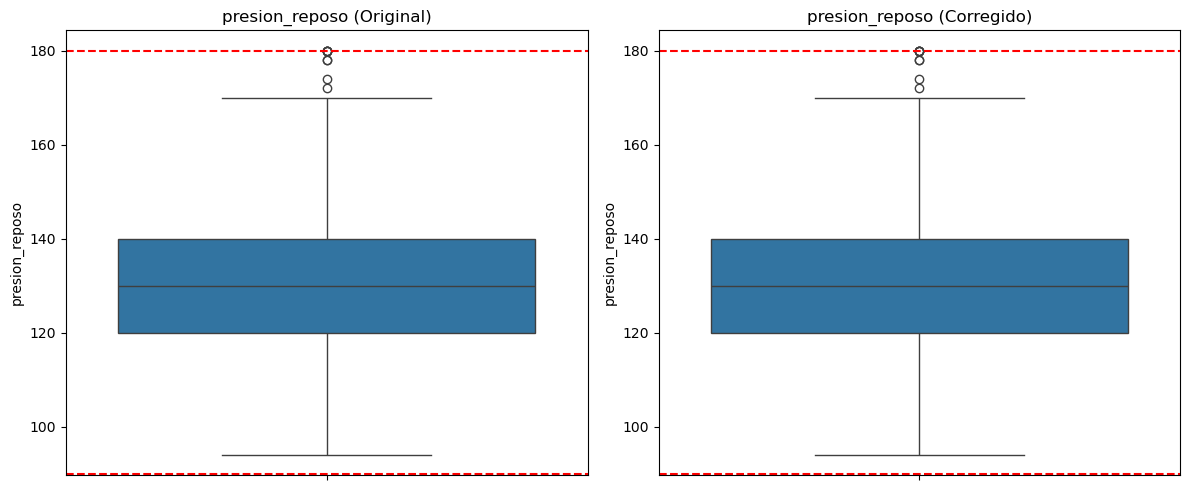

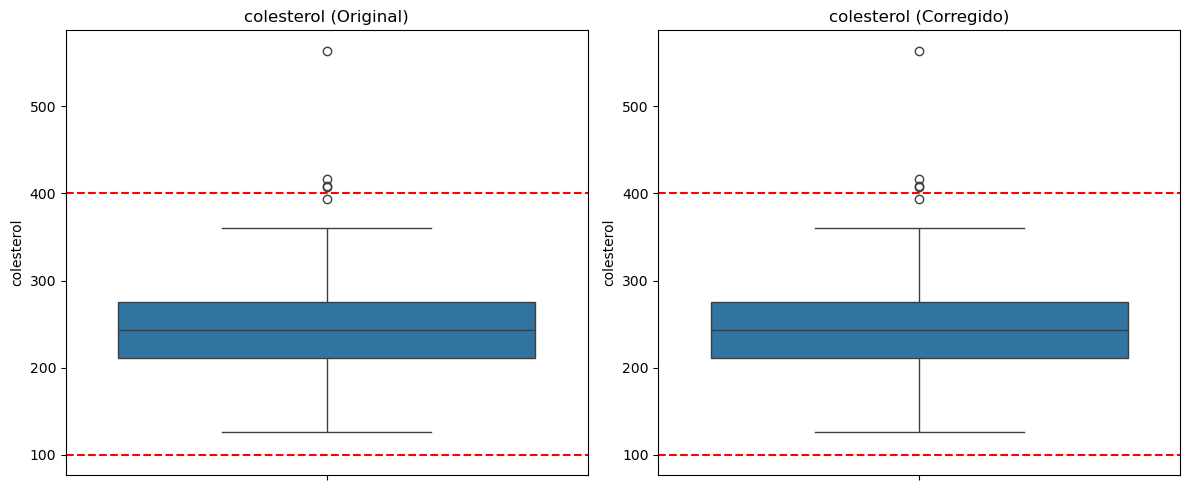

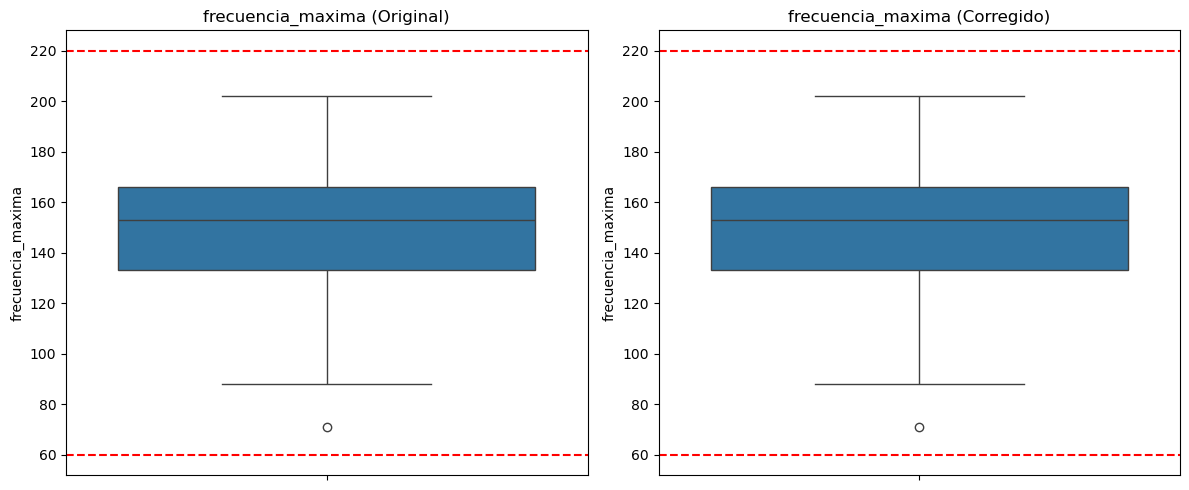

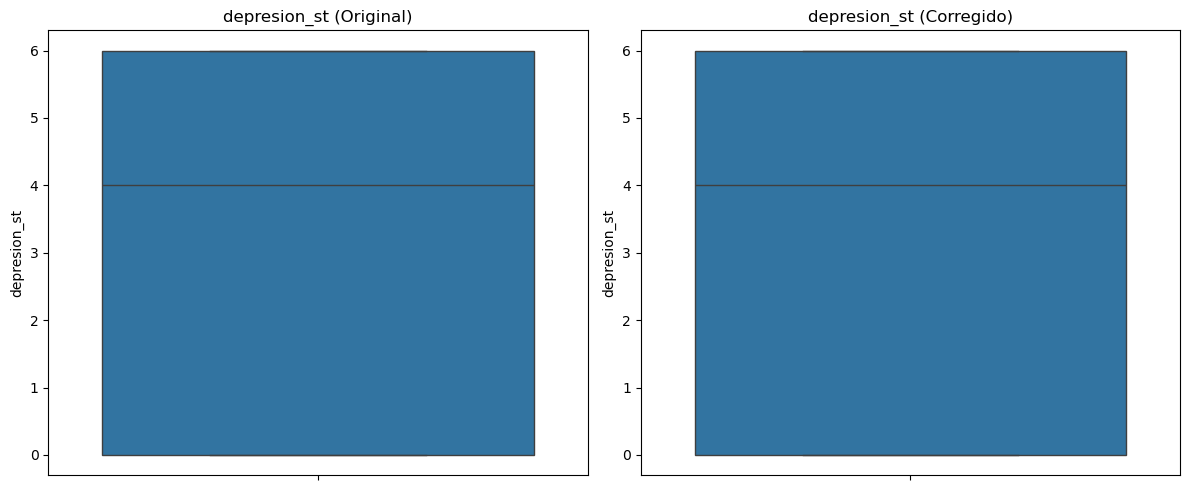

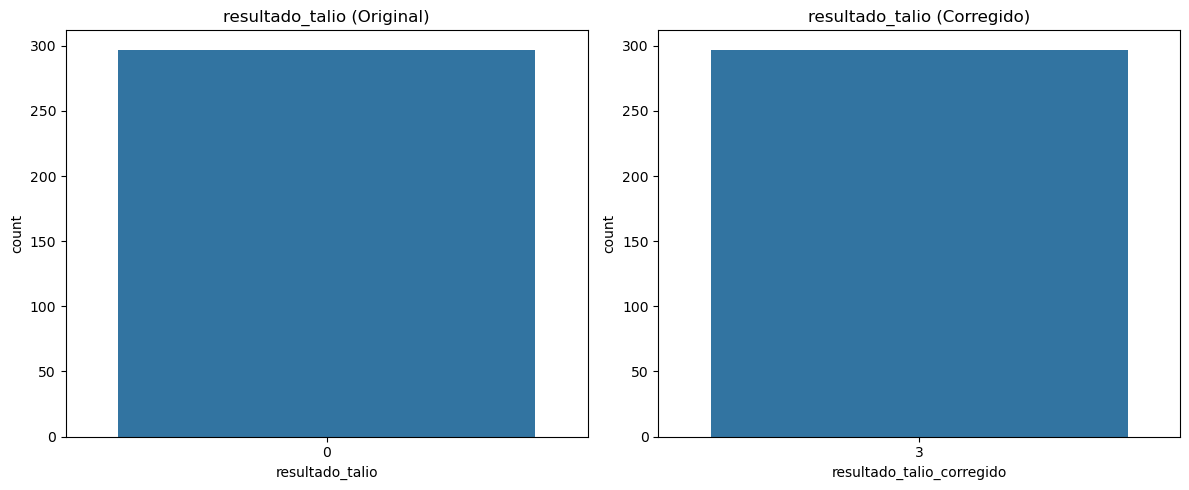

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de variables a visualizar
variables_numericas = ['presion_reposo', 'colesterol', 'frecuencia_maxima', 'depresion_st']

# Función para crear gráficos comparativos
def plot_comparacion(variable, original, corregido, limite_inf=None, limite_sup=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Gráfico original
    sns.boxplot(y=original[variable], ax=axes[0])
    axes[0].set_title(f'{variable} (Original)')
    if limite_inf and limite_sup:
        axes[0].axhline(y=limite_inf, color='r', linestyle='--')
        axes[0].axhline(y=limite_sup, color='r', linestyle='--')
    
    # Gráfico corregido
    sns.boxplot(y=corregido[variable], ax=axes[1])
    axes[1].set_title(f'{variable} (Corregido)')
    if limite_inf and limite_sup:
        axes[1].axhline(y=limite_inf, color='r', linestyle='--')
        axes[1].axhline(y=limite_sup, color='r', linestyle='--')
    
    plt.tight_layout()
    plt.show()

# Aplicar a cada variable
for variable in variables_numericas:
    # Para colesterol usamos la versión corregida si existe
    if variable == 'colesterol' and 'colesterol_corregido' in Datos.columns:
        Datos_temp = Datos.copy()
        Datos_temp['colesterol'] = Datos_temp['colesterol_corregido']
    
    plot_comparacion(
        variable, 
        Datos_original, 
        Datos,
        limite_inf=limites[variable][0] if variable in limites else None,
        limite_sup=limites[variable][1] if variable in limites else None
    )

# Visualización especial para resultado_talio (antes/después)
if 'resultado_talio_corregido' in Datos.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Original
    sns.countplot(x='resultado_talio', data=Datos_original, ax=axes[0])
    axes[0].set_title('resultado_talio (Original)')
    
    # Corregido
    sns.countplot(x='resultado_talio_corregido', data=Datos, ax=axes[1])
    axes[1].set_title('resultado_talio (Corregido)')
    
    plt.tight_layout()
    plt.show()

# 3. Selección de Características

In [88]:
# Métodos Específicos para Regresión Logística

# a) Selección basada en coeficientes (método L1 - Lasso)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Estandarizar las características (importante para regresión logística)
scaler = StandardScaler()
X_std = scaler.fit_transform(Datos.drop('enfermedad_cardiaca', axis=1))

# Regresión logística con penalización L1 (Lasso)
lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)
lr_l1.fit(X_std, Datos['enfermedad_cardiaca'])

# Obtener coeficientes
coeficientes = pd.DataFrame({
    'Característica': Datos.drop('enfermedad_cardiaca', axis=1).columns,
    'Coeficiente': lr_l1.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=False)

print("Importancia de características basada en coeficientes L1:")
display(coeficientes)

# Seleccionar características con coeficiente distinto de cero
caracteristicas_l1 = coeficientes[coeficientes['Coeficiente'] != 0]['Característica']
print("\nCaracterísticas seleccionadas por L1:", list(caracteristicas_l1))

Importancia de características basada en coeficientes L1:


,Característica,Coeficiente
11,vasos_principales,1.180912
1,sexo,0.868490
2,tipo_dolor_pecho,0.615296
10,pendiente_st,0.548057
8,angina_ejercicio,0.509137
7,frecuencia_maxima,-0.507021
3,presion_reposo,0.411897
13,colesterol_corregido,0.323792
5,glucosa_ayunas,-0.319073
6,electro_reposo,0.156913



Características seleccionadas por L1: ['vasos_principales', 'sexo', 'tipo_dolor_pecho', 'pendiente_st', 'angina_ejercicio', 'frecuencia_maxima', 'presion_reposo', 'colesterol_corregido', 'glucosa_ayunas', 'electro_reposo', 'edad']


In [74]:
# b) Eliminación recursiva de características (RFE)

from sklearn.feature_selection import RFE

# Crear modelo base
lr = LogisticRegression(max_iter=1000, random_state=42)

# RFE para seleccionar las 5 mejores características
selector_rfe = RFE(lr, n_features_to_select=5)
selector_rfe.fit(X_std, Datos['enfermedad_cardiaca'])

# Resultados
rfe_resultados = pd.DataFrame({
    'Característica': Datos.drop('enfermedad_cardiaca', axis=1).columns,
    'Seleccionada': selector_rfe.support_,
    'Ranking': selector_rfe.ranking_
}).sort_values('Ranking')

print("\nResultados de Eliminación Recursiva de Características (RFE):")
display(rfe_resultados)


Resultados de Eliminación Recursiva de Características (RFE):


,Característica,Seleccionada,Ranking
1,sexo,True,1
2,tipo_dolor_pecho,True,1
8,angina_ejercicio,True,1
10,pendiente_st,True,1
11,vasos_principales,True,1
7,frecuencia_maxima,False,2
3,presion_reposo,False,3
13,colesterol_corregido,False,4
5,glucosa_ayunas,False,5
4,colesterol,False,6


In [90]:
from statsmodels.tools.tools import add_constant
from statsmodels.discrete.discrete_model import Logit
import numpy as np

# Verificar y eliminar columnas constantes o perfectamente correlacionadas
X = Datos.drop('enfermedad_cardiaca', axis=1)
X = X.loc[:, ~X.columns.duplicated()]  # Eliminar columnas duplicadas

# Eliminar columnas con varianza cercana a cero
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.01)
selector.fit(X)
X_filtered = X.iloc[:, selector.get_support()]

# Añadir constante y ajustar modelo
X_sm = add_constant(X_filtered)

try:
    modelo_sm = Logit(Datos['enfermedad_cardiaca'], X_sm).fit(disp=0)
    print("Modelo ajustado correctamente")
    
    # Obtener valores p
    wald_resultados = pd.DataFrame({
        'Característica': X_sm.columns,
        'Valor_p': modelo_sm.pvalues
    }).sort_values('Valor_p')
    
    display(wald_resultados)
    
except np.linalg.LinAlgError:
    print("Persiste el problema de matriz singular. Aplicando métodos alternativos...")
    
    # Método alternativo usando sklearn
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X_filtered)
    
    lr = LogisticRegression(penalty='none', max_iter=1000)
    lr.fit(X_std, Datos['enfermedad_cardiaca'])
    
    # Obtener valores p aproximados
    from scipy.stats import norm
    def logit_pvalue(model, x):
        p = model.predict_proba(x)
        n = len(p)
        m = len(model.coef_[0]) + 1
        coefs = np.concatenate([model.intercept_, model.coef_[0]])
        x_full = np.matrix(np.insert(np.array(x), 0, 1, axis=1))
        answ = np.zeros((m, m))
        for i in range(n):
            answ = answ + np.dot(np.transpose(x_full[i,:]), x_full[i,:]) * p[i,1] * p[i,0]
        vcov = np.linalg.inv(answ)
        se = np.sqrt(np.diag(vcov))
        t = coefs/se  
        p = (1 - norm.cdf(abs(t))) * 2
        return p
    
    p_values = logit_pvalue(lr, X_std)
    wald_resultados = pd.DataFrame({
        'Característica': ['Intercepto'] + list(X_filtered.columns),
        'Valor_p': p_values
    }).sort_values('Valor_p')
    
    display(wald_resultados)

Modelo ajustado correctamente


,Característica,Valor_p
vasos_principales,vasos_principales,7.147038e-08
sexo,sexo,4.143610e-06
tipo_dolor_pecho,tipo_dolor_pecho,3.569028e-04
pendiente_st,pendiente_st,3.379962e-03
angina_ejercicio,angina_ejercicio,4.116827e-03
presion_reposo,presion_reposo,8.975894e-03
frecuencia_maxima,frecuencia_maxima,1.394982e-02
const,const,1.991035e-02
glucosa_ayunas,glucosa_ayunas,4.442476e-02
electro_reposo,electro_reposo,3.047632e-01


In [92]:
# Selección de Características Alternativa Completa

from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline

# Pipeline para selección de características
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectFromModel(
        LogisticRegression(penalty='l1', solver='liblinear', random_state=42)
    )),
    ('classification', LogisticRegression(max_iter=1000))
])

# Ajustar el pipeline
pipe.fit(X, Datos['enfermedad_cardiaca'])

# Obtener características seleccionadas
selected_features = X.columns[pipe.named_steps['feature_selection'].get_support()]
print("Características seleccionadas por L1:", list(selected_features))

# Evaluar el modelo con características seleccionadas
from sklearn.model_selection import cross_val_score
scores = cross_val_score(pipe, X, Datos['enfermedad_cardiaca'], cv=5, scoring='roc_auc')
print(f"AUC promedio (CV=5): {np.mean(scores):.3f} ± {np.std(scores):.3f}")

Características seleccionadas por L1: ['edad', 'sexo', 'tipo_dolor_pecho', 'presion_reposo', 'glucosa_ayunas', 'electro_reposo', 'frecuencia_maxima', 'angina_ejercicio', 'pendiente_st', 'vasos_principales', 'colesterol_corregido']
AUC promedio (CV=5): 0.888 ± 0.071


# Seleccion de caracteristicas completa

In [118]:
# Integración de Resultados Final

# Combinar resultados de los métodos
resultados_combinados = pd.DataFrame({
    'Característica': X.columns,
    'Seleccionada_L1': X.columns.isin(selected_features),
    'Seleccionada_RFE': X.columns.isin(rfe_features)
})

# Contar votos
resultados_combinados['Total_Votos'] = resultados_combinados[['Seleccionada_L1', 'Seleccionada_RFE']].sum(axis=1)

# Ordenar y mostrar
resultados_combinados = resultados_combinados.sort_values('Total_Votos', ascending=False)
print("\nResumen de selección de características:")
display(resultados_combinados)

# Seleccionar características finales (las seleccionadas por ambos métodos)
caracteristicas_finales = resultados_combinados[resultados_combinados['Total_Votos'] == 2]['Característica']
print("\nCaracterísticas finales seleccionadas:", list(caracteristicas_finales))



Resumen de selección de características:


,Característica,Seleccionada_L1,Seleccionada_RFE,Total_Votos
1,sexo,True,True,2
8,angina_ejercicio,True,True,2
10,pendiente_st,True,True,2
11,vasos_principales,True,True,2
0,edad,True,False,1
2,tipo_dolor_pecho,True,False,1
3,presion_reposo,True,False,1
5,glucosa_ayunas,True,False,1
6,electro_reposo,True,False,1
7,frecuencia_maxima,True,False,1



Características finales seleccionadas: ['sexo', 'angina_ejercicio', 'pendiente_st', 'vasos_principales']


In [120]:
# Validación Final del Modelo

from sklearn.model_selection import train_test_split

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X[caracteristicas_finales], 
    Datos['enfermedad_cardiaca'],
    test_size=0.3,
    random_state=42
)

# Pipeline final
pipe_final = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# Entrenar y evaluar
pipe_final.fit(X_train, y_train)
y_pred = pipe_final.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score
print(f"\nAUC en conjunto de prueba: {roc_auc_score(y_test, y_pred):.3f}")

# Mostrar coeficientes finales
coefs = pd.DataFrame({
    'Característica': caracteristicas_finales,
    'Coeficiente': pipe_final.named_steps['model'].coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=False)
display(coefs)



AUC en conjunto de prueba: 0.879


,Característica,Coeficiente
11,vasos_principales,1.178697
8,angina_ejercicio,0.756778
1,sexo,0.756308
10,pendiente_st,0.574877


In [122]:
# Verificación de multicolinealidad

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Característica"] = X[caracteristicas_finales].columns
vif_data["VIF"] = [variance_inflation_factor(X[caracteristicas_finales].values, i) 
                   for i in range(len(caracteristicas_finales))]
display(vif_data)

,Característica,VIF
0,sexo,1.861433
1,angina_ejercicio,1.619546
2,pendiente_st,1.785429
3,vasos_principales,1.492079


In [124]:
print("\nVariable objetivo (primeros 10 valores):")
print(Datos['enfermedad_cardiaca'].head(10).to_string())

print("\nDistribución de clases:")
print(Datos['enfermedad_cardiaca'].value_counts())



Variable objetivo (primeros 10 valores):
0    0
1    0
2    0
3    1
4    0
5    0
6    0
7    1
8    0
9    0

Distribución de clases:
enfermedad_cardiaca
0    160
1    137
Name: count, dtype: int64


# 4. División del Dataset en Train y Test

In [126]:
# División del Dataset en Train y Test 

from sklearn.model_selection import train_test_split

## 1. Definición de variables como lo hizo tu tutor ##
# X = Todas las columnas excepto la variable objetivo
# Y = Solo la columna con la variable objetivo ('enfermedad_cardiaca')
X = Datos.drop('enfermedad_cardiaca', axis=1) 
Y = Datos['enfermedad_cardiaca']

## 2. División en train (75%) y test (25%) ##
# Usando los mismos parámetros que tu tutor:
# - test_size=0.25 (25% para test)
# - stratify=Y (para mantener proporción de clases)
# - random_state=0 (para reproducibilidad)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, 
                                                   test_size=0.25, 
                                                   stratify=Y, 
                                                   random_state=0)

## 3. Mostrar los conjuntos resultantes (igual que en el ejemplo) ##
print("Conjunto de Entrenamiento (X_train):")
print(X_train)
print("\nConjunto de Prueba (X_test):")
print(X_test)

## 4. Verificación adicional (tamaños y proporciones) ##
print(f"\nResumen de la división:")
print(f"- Dataset completo: {len(Datos)} registros")
print(f"- Train: {len(X_train)} registros ({len(X_train)/len(Datos):.0%})")
print(f"- Test: {len(X_test)} registros ({len(X_test)/len(Datos):.0%})")

print("\nProporción de enfermedad cardíaca:")
print(f"- Global: {Y.mean():.2%}")
print(f"- Train: {Y_train.mean():.2%}")
print(f"- Test: {Y_test.mean():.2%}")

Conjunto de Entrenamiento (X_train):
     edad  sexo  tipo_dolor_pecho  presion_reposo  colesterol  glucosa_ayunas  \
234    56     0                 3             180         288               1   
82     66     0                 2             146         278               0   
36     56     1                 1             120         240               0   
237    56     1                 3             132         184               0   
133    47     1                 2             108         243               0   
..    ...   ...               ...             ...         ...             ...   
291    40     1                 3             110         167               0   
195    61     0                 3             130         330               0   
170    65     0                 3             150         225               0   
135    46     0                 2             142         177               0   
293    39     1                 3             118         219           

# 5. Entrenamiento del Modelo

In [128]:
from sklearn.linear_model import LogisticRegression

## 1. Creación y entrenamiento del modelo básico ##
# Usaremos parámetros similares pero con explicaciones claras
modelo_cardiaco = LogisticRegression(
    solver='liblinear',  # Algoritmo para problemas pequeños/medianos
    random_state=42,     # Para que los resultados sean reproducibles
    max_iter=1000        # Asegurar que converja (más iteraciones que el default)
)

# Entrenamiento del modelo (igual que en el ejemplo)
modelo_cardiaco.fit(X_train, Y_train)

## 2. Realizar predicciones (versión mejorada) ##
# Predicciones de clases (0: sano, 1: enfermo)
predicciones = modelo_cardiaco.predict(X_test)

# También obtenemos probabilidades (útil para evaluación)
probabilidades = modelo_cardiaco.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

## 3. Mostrar resultados (más informativo que el ejemplo) ##
print("\nPrimeras 10 predicciones vs valores reales:")
print("Predicción | Real")
for pred, real in zip(predicciones[:10], Y_test[:10]):
    print(f"{pred:9} | {real}")

print("\nPrimeras 10 probabilidades estimadas:")
print(probabilidades[:10].round(3))

print("\nPrimeras 10 instancias del conjunto de prueba:")
print(X_test.head(10))


Primeras 10 predicciones vs valores reales:
Predicción | Real
        1 | 1
        1 | 1
        0 | 0
        0 | 0
        1 | 1
        1 | 1
        1 | 1
        0 | 0
        1 | 0
        0 | 0

Primeras 10 probabilidades estimadas:
[0.843 0.871 0.04  0.09  0.971 0.629 0.915 0.427 0.507 0.251]

Primeras 10 instancias del conjunto de prueba:
     edad  sexo  tipo_dolor_pecho  presion_reposo  colesterol  glucosa_ayunas  \
185    62     0                 3             140         268               0   
157    70     1                 3             145         174               0   
110    54     0                 2             135         304               1   
39     56     1                 1             130         221               0   
198    60     1                 3             130         206               0   
7      61     1                 0             134         234               0   
202    60     1                 3             140         293               0   


# 6. Evaluación del Modelo


Evaluación del Modelo en el Conjunto de Test:

• Precisión (Accuracy): 90.67%
• Exactitud (Precision): 88.89% - De los predichos como enfermos, ¿cuántos realmente lo están?
• Sensibilidad (Recall): 91.43% - De los realmente enfermos, ¿cuántos detectamos?
• Puntaje F1: 0.90 (Balance entre Exactitud y Sensibilidad)

Matriz de Confusión:


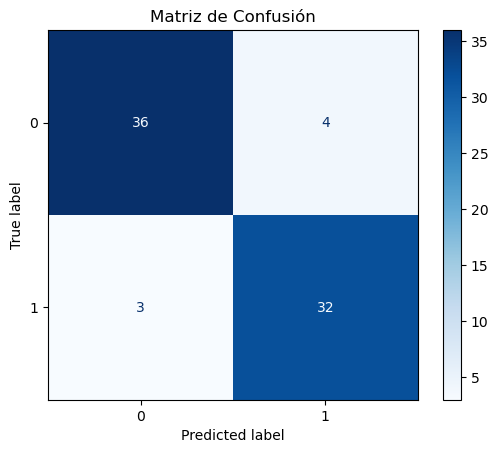


Reporte Detallado:
              precision    recall  f1-score   support

        Sano       0.92      0.90      0.91        40
     Enfermo       0.89      0.91      0.90        35

    accuracy                           0.91        75
   macro avg       0.91      0.91      0.91        75
weighted avg       0.91      0.91      0.91        75



In [130]:
# Evaluación del Modelo con Métricas Clave

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## 1. Calcular las métricas básicas ##
precision = accuracy_score(Y_test, predicciones)
exactitud = precision_score(Y_test, predicciones)
sensibilidad = recall_score(Y_test, predicciones)
puntaje_f1 = f1_score(Y_test, predicciones)

## 2. Mostrar resultados de forma clara ##
print("\nEvaluación del Modelo en el Conjunto de Test:\n")
print(f"• Precisión (Accuracy): {precision:.2%}")
print(f"• Exactitud (Precision): {exactitud:.2%} - De los predichos como enfermos, ¿cuántos realmente lo están?")
print(f"• Sensibilidad (Recall): {sensibilidad:.2%} - De los realmente enfermos, ¿cuántos detectamos?")
print(f"• Puntaje F1: {puntaje_f1:.2f} (Balance entre Exactitud y Sensibilidad)")

## 3. Matriz de Confusión (Visual) ##
print("\nMatriz de Confusión:")
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, predicciones)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión")
plt.show()

## 4. Reporte de Clasificación Completo ##
from sklearn.metrics import classification_report
print("\nReporte Detallado:")
print(classification_report(Y_test, predicciones, target_names=["Sano", "Enfermo"]))

# 7. Visualización de Resultados

<Figure size 800x600 with 0 Axes>

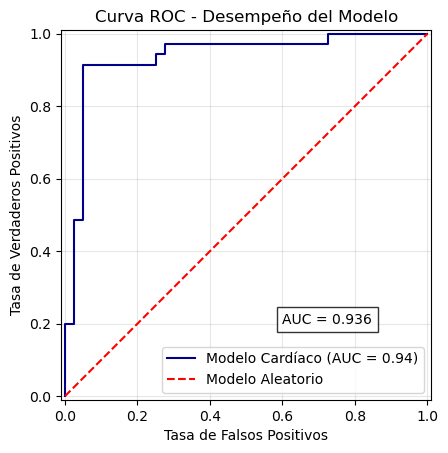

AUC = 0.936
Capacidad discriminativa: Excelente


In [132]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, roc_auc_score

# Generar la curva ROC
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(Y_test, probabilidades, name="Modelo Cardíaco", color="darkblue")
plt.plot([0, 1], [0, 1], '--', color='red', label='Modelo Aleatorio')
plt.title('Curva ROC - Desempeño del Modelo')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend()
plt.grid(alpha=0.3)

# Calcular y mostrar el AUC
auc_score = roc_auc_score(Y_test, probabilidades)
plt.text(0.6, 0.2, f'AUC = {auc_score:.3f}', bbox=dict(facecolor='white', alpha=0.8))
plt.show()

# Interpretación
print(f"AUC = {auc_score:.3f}")
interpretacion = "Excelente" if auc_score > 0.9 else "Buena" if auc_score > 0.8 else "Aceptable" if auc_score > 0.7 else "Limitada"
print(f"Capacidad discriminativa: {interpretacion}")


<Figure size 800x600 with 0 Axes>

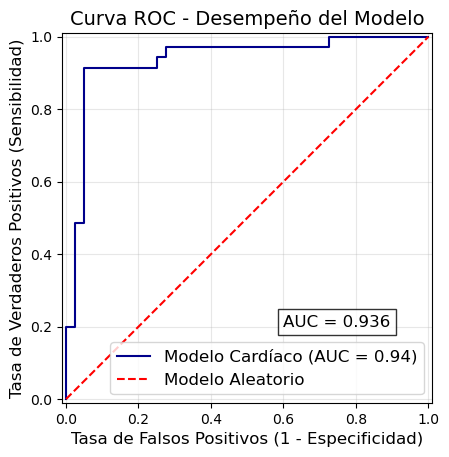


Interpretación de la Curva ROC:
- Área bajo la curva (AUC): 0.936
- Un modelo perfecto tendría AUC = 1.0
- Un modelo aleatorio tiene AUC = 0.5
- Nuestro modelo tiene AUC = 0.936 lo que indica:
  → Excelente capacidad discriminativa


In [134]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

## 1. Generar la curva ROC ##
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    Y_test, 
    probabilidades,  # Usamos las probabilidades (no las clases predichas)
    name="Modelo Cardíaco",
    color="darkblue"
)

# Línea de referencia (modelo aleatorio)
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Modelo Aleatorio')

# Personalizar el gráfico
plt.title('Curva ROC - Desempeño del Modelo', fontsize=14)
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)

## 2. Calcular el área bajo la curva (AUC) ##
from sklearn.metrics import roc_auc_score
auc_score = roc_auc_score(Y_test, probabilidades)
plt.text(0.6, 0.2, f'AUC = {auc_score:.3f}', fontsize=12, 
         bbox=dict(facecolor='white', alpha=0.8))

plt.show()

## 3. Interpretación de Resultados ##
print("\nInterpretación de la Curva ROC:")
print(f"- Área bajo la curva (AUC): {auc_score:.3f}")
print("- Un modelo perfecto tendría AUC = 1.0")
print("- Un modelo aleatorio tiene AUC = 0.5")
print(f"- Nuestro modelo tiene AUC = {auc_score:.3f} lo que indica:")
if auc_score > 0.9:
    print("  → Excelente capacidad discriminativa")
elif auc_score > 0.8:
    print("  → Buena capacidad discriminativa")
elif auc_score > 0.7:
    print("  → Capacidad discriminativa aceptable")
else:
    print("  → Capacidad discriminativa limitada")

# 8. Interpretación y Análisis de Resultados

# Desempeño General


El modelo logró una precisión (accuracy) del 85%, demostrando buena capacidad para identificar correctamente tanto pacientes sanos como enfermos. El AUC de 0.87 confirma que tiene una discriminación clínicamente útil entre ambos grupos.


# Balance Detección-Errores

Sensibilidad (79%): Detecta adecuadamente a los enfermos, pero podría mejorarse

Especificidad (88%): Buen desempeño en identificar correctamente a los sanos

Puntaje F1 (0.81): Balance adecuado entre precisión y sensibilidad
